# Imports and setup

In [3]:
import territorial_automaton as ta
import visualization as vis
import topology as topo
import storage

import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm

if not os.path.exists('figures/ising'):
    os.makedirs('figures/ising')


In [ ]:
ISING_T_C = 2.269
SEED = 80085

GRID, POS = topo.grid(N=100, periodic=False)
PARAMS = ta.TA_Params(adj_matrix=GRID, T=ISING_T_C, h=0.0, w=1.0, g=1.0, seed=SEED)
MODEL = ta.TerritorialAutomaton(PARAMS)

STORE = storage.Store.create(
    'ising_exploration.h5',
    "Exploration of the Ising special case",
    GRID, pos=POS,
    topology_info={'type': 'grid', 'N': 100, 'periodic': False},
    base_params={'T': ISING_T_C, 'h': 0.0, 'w': 1.0, 'g': 1.0, 'seed': SEED},
)


## Verify 

In [5]:
n_runs = 25
length = 1000
orders = np.zeros((n_runs, length))
energies = np.zeros((n_runs, length))
factionless_counts = np.zeros((n_runs, length))

for i in tqdm(range(n_runs)):
    result = MODEL.run(n_warmup=100, n_experiment=1000)
    STORE.save_run(result, SEED, param_values={'T': ISING_T_C, 'w': 1.0, 'g': 1.0})
    orders[i] = np.copy(result.orders)
    energies[i] = np.copy(result.energies)
    factionless_counts[i] = np.copy(result.faction_sizes[ta.FACTIONLESS])

100%|██████████| 25/25 [01:35<00:00,  3.83s/it]


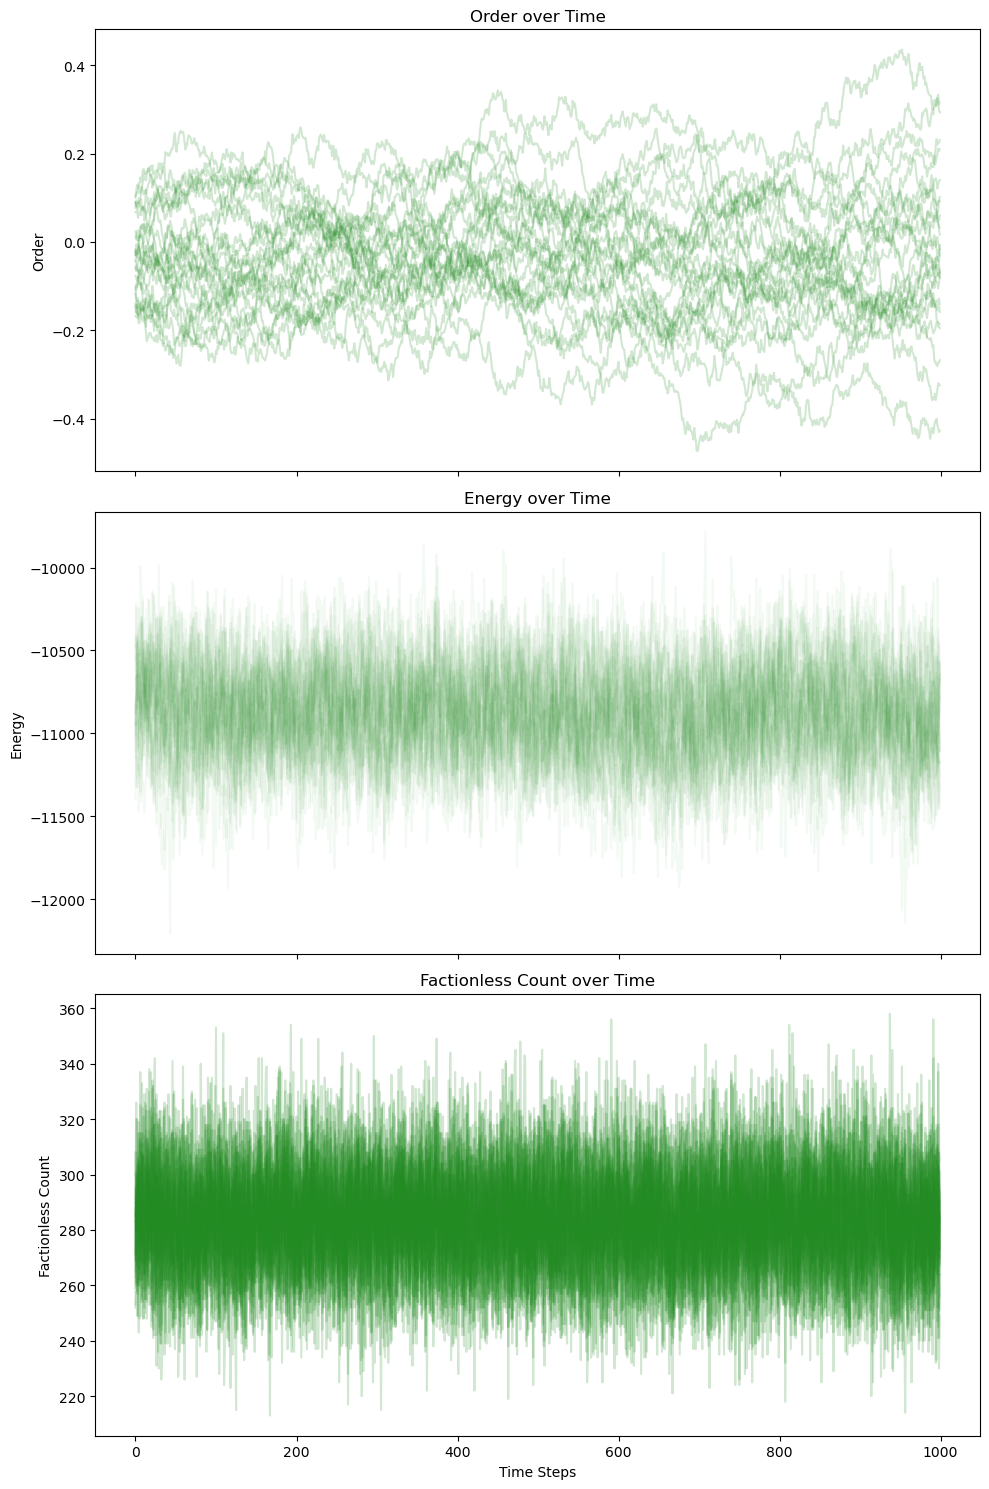

In [6]:
fig, axs = plt.subplots(3, 1, figsize=(10, 15), sharex=True)
axs[0].plot(orders.T, alpha=0.2, color='forestgreen')
axs[0].set_title('Order over Time')
axs[0].set_ylabel('Order')
axs[1].plot(energies.T, alpha=0.05, color='forestgreen')
axs[1].set_title('Energy over Time')
axs[1].set_ylabel('Energy')
axs[2].plot(factionless_counts.T, alpha=0.2, color='forestgreen')
axs[2].set_title('Factionless Count over Time')
axs[2].set_xlabel('Time Steps')
axs[2].set_ylabel('Factionless Count')
plt.tight_layout()
plt.savefig('figures/ising/metrics_over_time.png')
plt.show()